In [12]:
#import libraries
import pandas as pd
import os
import glob as glob
import matplotlib.pyplot as plt

# Import data
I will first import the threshold estimates for 65% accuracy from the data frame I already made by running Bayesian_threshold_estimation.py. This contains the informative Bayesian estimate, the Bayesian estimate with a flat prior, and the GLM estimate.

I will also add a column to this dataframe which adds the opacity of the final block per participant

In [8]:
#import thrreshold estimates previously made
results_df = pd.read_csv("threshold_estimates.csv")

final_opacities = []

#import final opacity per person from main blocks
for _, row in results_df.iterrows():
    subject_id = row['subject']
    subject_dir = f"Data/individual_data/{subject_id}/"
    
    # Find the final_opac file — name varies by subject
    opac_files = glob.glob(f"{subject_dir}*final_opac.csv")
    
    if not opac_files:
        print(f"No final_opac file found for {subject_id}")
        final_opacities.append(np.nan)
        continue
    
    opac_df = pd.read_csv(opac_files[0])
    final_opacity = opac_df.iloc[-1, 0]  # last row, second column
    final_opacities.append(final_opacity)

#merge dataframes
results_df['final_opacity'] = final_opacities
print(results_df)
results_df.to_csv("Data/threshold_estimates_with_opacity.csv", index=False)

      subject  glm_threshold  bayesian_informative  bayesian_info_hdi_low  \
0   sub10MPV3       0.253743              0.279321               0.224430   
1     sub11MP       0.261586              0.269705               0.211732   
2   sub11MPV3       0.246169              0.256005               0.198195   
3     sub12MP       0.142433              0.183442               0.124982   
4   sub12MPV3       0.372699              0.365198               0.311780   
5     sub13MP       0.388208              0.364693               0.314234   
6   sub13MPV3       0.205128              0.232124               0.175267   
7     sub14MP       0.268343              0.275741               0.220961   
8   sub14MPV3       0.188901              0.194788               0.134788   
9     sub15MP       0.279619              0.286300               0.231811   
10  sub15MPV3       0.298592              0.302748               0.247793   
11    sub16MP       0.332745              0.333455               0.278654   

I am then reimporting the new dataframe and redefining the priors.

In [ ]:
#import the new data frame
results_df = pd.read_csv("Data/threshold_estimates_with_opacity.csv")

#establish priors
prior_mean = 0.264
prior_sd   = 0.085
slope      = 7.60
target     = 0.65

# Plotting

I am creating a two panel figure:
Top:    GLM (frequentist) vs Bayesian (informative prior)
Bottom: Bayesian vs final Opacity (e.g. in theory, what the final adapted value was)

Grey lines connect the two estimates for the same participant, allowing for visualisation of where the priors diverge.
The dashed horizontal line marks the Bayesian prior mean.

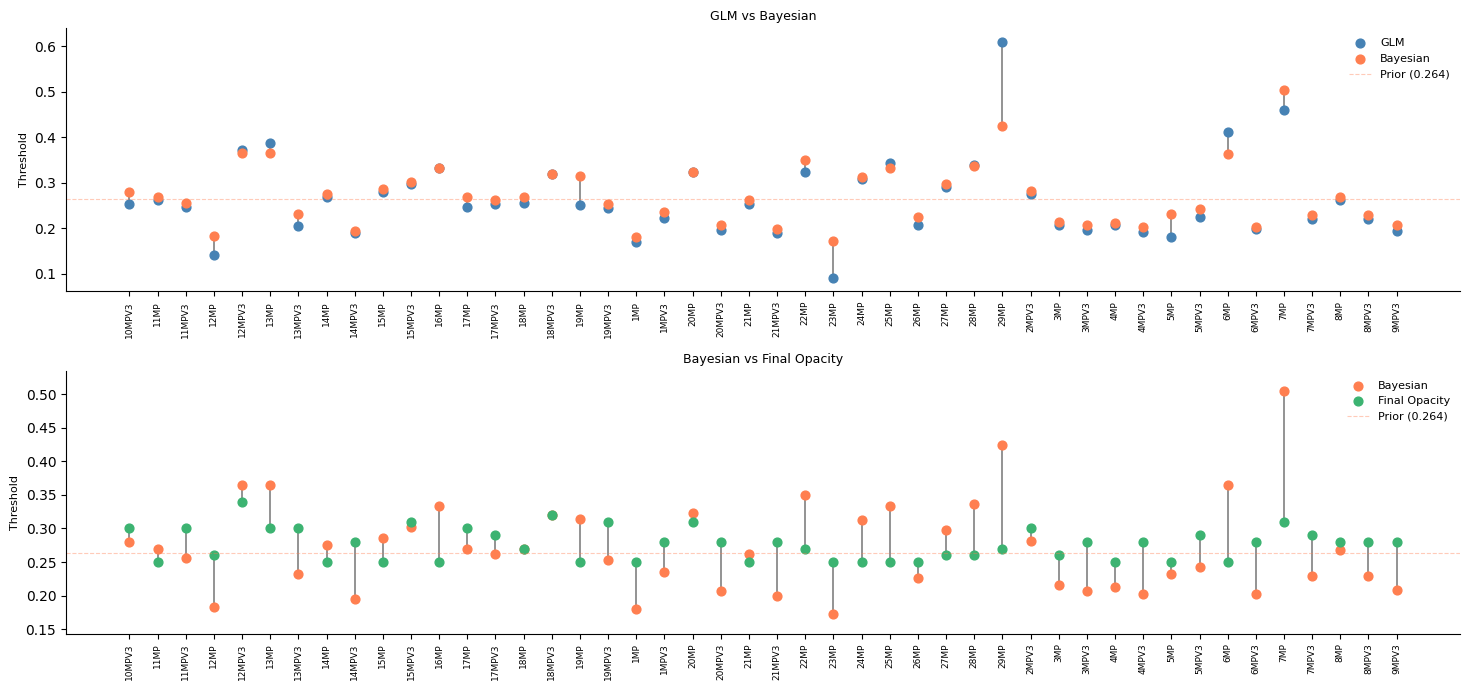

In [ ]:


# --- Create a short label for each participant (e.g. "01a" from "sub01a") ---
results_df['short_label'] = results_df['subject'].str.extract(r'sub(\d+\w+)')

# --- Set up a 2-row figure, width scaled to participant count ---
fig, axes = plt.subplots(2, 1, figsize=(len(results_df) * 0.3 + 1, 7))

# ===================================================================
# Top plot: GLM vs Bayesian
# ===================================================================
# Shows how much the Bayesian informative prior pulls each
# participant's threshold estimate away from the pure-data GLM.
# Large grey lines indicate strong prior influence
# ===================================================================
ax = axes[0]

# --- Grey connector lines between GLM and Bayesian for each participant ---
for _, row in results_df.iterrows():
    ax.plot(
        [row['short_label'], row['short_label']],
        [row['glm_threshold'], row['bayesian_informative']],
        color='grey', linewidth=1.2, zorder=1
    )

# --- Scatter points for each method ---
ax.scatter(results_df['short_label'], results_df['glm_threshold'],
           color='steelblue', zorder=2, s=40, label='GLM')
ax.scatter(results_df['short_label'], results_df['bayesian_informative'],
           color='coral', zorder=2, s=40, label='Bayesian')

# --- Horizontal reference line at the prior mean ---
ax.axhline(prior_mean, color='coral', linestyle='--',
           linewidth=0.8, alpha=0.4, label=f'Prior ({prior_mean})')

# --- Y-axis limits with small padding ---
pad = 0.03
ymin = results_df[['glm_threshold', 'bayesian_informative']].min().min() - pad
ymax = results_df[['glm_threshold', 'bayesian_informative']].max().max() + pad
ax.set_ylim(ymin, ymax)

ax.set_ylabel('Threshold', fontsize=8)
ax.set_title('GLM vs Bayesian', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', labelrotation=90, labelsize=6.5)
ax.legend(frameon=False, fontsize=8)

# ===================================================================
# Bottom plot: Bayesian vs Final Opacity
# ===================================================================
# Compares the Bayesian model-based threshold to the final opacity
# reached by the adaptive staircase procedure. Agreement validates
# both methods; divergence may indicate the staircase hadn't
# converged or the model is a poor fit for that participant.
# ===================================================================
ax = axes[1]

# --- Grey connector lines ---
for _, row in results_df.iterrows():
    ax.plot(
        [row['short_label'], row['short_label']],
        [row['bayesian_informative'], row['final_opacity']],
        color='grey', linewidth=1.2, zorder=1
    )

# --- Scatter points ---
ax.scatter(results_df['short_label'], results_df['bayesian_informative'],
           color='coral', zorder=2, s=40, label='Bayesian')
ax.scatter(results_df['short_label'], results_df['final_opacity'],
           color='mediumseagreen', zorder=2, s=40, label='Final Opacity')

# --- Prior reference line ---
ax.axhline(prior_mean, color='coral', linestyle='--',
           linewidth=0.8, alpha=0.4, label=f'Prior ({prior_mean})')

# --- Y-axis limits ---
pad = 0.03
ymin = results_df[['bayesian_informative', 'final_opacity']].min().min() - pad
ymax = results_df[['bayesian_informative', 'final_opacity']].max().max() + pad
ax.set_ylim(ymin, ymax)

ax.set_ylabel('Threshold', fontsize=8)
ax.set_title('Bayesian vs Final Opacity', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', labelrotation=90, labelsize=6.5)
ax.legend(frameon=False, fontsize=8)

# --- Save and display ---
plt.tight_layout()
plt.savefig('threshold_comparison.png', dpi=150, bbox_inches='tight')
plt.show()